In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

## Load Data

In [2]:
try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# load f1 only
function_folder = os.path.join(base_dir, "function_1")
inputs = np.load(os.path.join(function_folder, "initial_inputs.npy"))
outputs = np.load(os.path.join(function_folder, "initial_outputs.npy"))

# reshape if needed
if inputs.ndim == 1:
    inputs = inputs.reshape(-1, 1)
if outputs.ndim == 1:
    outputs = outputs.reshape(-1, 1)

# create dataframe
input_cols = [f"X{j+1}" for j in range(inputs.shape[1])]
output_cols = [f"y{j+1}" for j in range(outputs.shape[1])]

df_f1 = pd.DataFrame(
    np.concatenate([inputs, outputs], axis=1),
    columns=input_cols + output_cols
)

print(f"Loaded function 1: shape = {df_f1.shape}, columns = {df_f1.columns.tolist()}")



Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 1: shape = (10, 3), columns = ['X1', 'X2', 'y1']


In [3]:
week1_results = {"f1": ([0.793600, 0.666269], 1.4034986520274933e-21),}

In [4]:
week2_results = {"f1": ([0.800601, 0.002800], 9.069108791316283e-223)}

In [5]:
week3_results = {"f1": ([0.729726, 0.729276], 5.31459276351908e-15),}

In [6]:
week4_results = {"f1": ([0.732162, 0.364472], 5.473776123300507e-57),}

In [7]:
week5_results = {"f1": ([0.812650, 0.143347], -1.0629331180647184e-161),}

In [8]:
week6_results = {"f1": ([0.079265, 0.909848], 2.6078826238924974e-248),}

In [9]:
week7_results = {"f1": ([0.525569, 0.987823], 2.2360328065267756e-98),}

In [10]:
week8_results = {"f1": ([0.994902, 0.994221], 3.029971271826444e-187),}

In [11]:
week9_results = {"f1": ([0.684583, 0.725353], 1.8670441080687443e-9),}

In [12]:
week10_results = {"f1": ([0.684583, 0.718000], 2.03320460262336e-8),}

In [13]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week4": week4_results,
    "week5": week5_results,
    "week6": week6_results,
    "week7": week7_results,
    "week8": week8_results,
    "week9": week9_results,
    "week10": week10_results,
}

output_col = output_cols[0]   # this gives "y1"

# add weekly results to df_f1

for week, results in weekly_results.items():
    
    if "f1" not in results:
        continue
    
    inputs, output = results["f1"]
    
    # convert to numpy arrays
    inputs = np.array(inputs).reshape(1, -1)
    output = np.array([output]).reshape(1, -1)
    
    # build dataframe row with the same columns as df_f1
    df_new_row = pd.DataFrame(
        np.concatenate([inputs, output], axis=1),
        columns=["X1", "X2", "y1"]
    )
    
    # append to df_f1
    df_f1 = pd.concat([df_f1, df_new_row], ignore_index=True)
    
    # remove duplicates
    df_f1 = df_f1.drop_duplicates(ignore_index=True)

print("updated f1 shape:", df_f1.shape)


updated f1 shape: (20, 3)


In [14]:
print(df_f1)

          X1        X2             y1
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.793600  0.666269   1.403499e-21
11  0.800601  0.002800  9.069109e-223
12  0.729726  0.729276   5.314593e-15
13  0.732162  0.364472   5.473776e-57
14  0.812650  0.143347 -1.062933e-161
15  0.079265  0.909848  2.607883e-248
16  0.525569  0.987823   2.236033e-98
17  0.994902  0.994221  3.029971e-187
18  0.684583  0.725353   1.867044e-09
19  0.684583  0.718000   2.033205e-08


In [15]:
display(df_f1.describe().T)  

,count,mean,std,min,25%,50%,75%,max
X1,20.0,0.61629,0.254389,0.079265,4.967860e-01,6.845830e-01,7.953503e-01,9.949020e-01
X2,20.0,0.58183,0.315542,0.002800,3.395369e-01,6.997632e-01,7.874839e-01,9.942210e-01
y1,20.0,-0.00018,0.000806,-0.003606,6.801832e-223,6.793724e-80,3.508747e-22,2.033205e-08


## Pearson Correlation

f1 Pearson Correlation Matrix (raw y1)


,X1,X2,y1
X1,1.000000,0.010175,-0.031295
X2,0.010175,1.000000,-0.074367
y1,-0.031295,-0.074367,1.000000


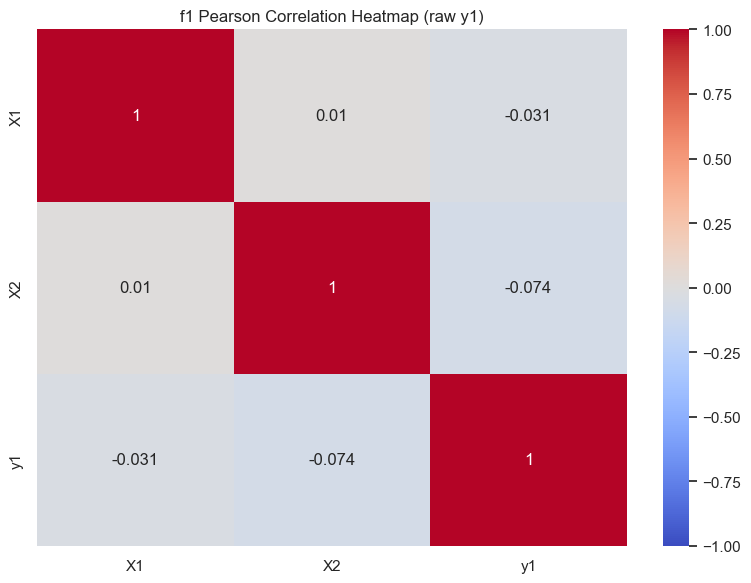

In [16]:
df_raw = df_f1.copy()

print("f1 Pearson Correlation Matrix (raw y1)")

corr_raw = df_raw.corr()
display(corr_raw)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f1 Pearson Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()

f1 Pearson Correlation Matrix (copula-transformed y1)


,X1,X2,y1
X1,1.000000,0.010175,0.259090
X2,0.010175,1.000000,0.429855
y1,0.259090,0.429855,1.000000


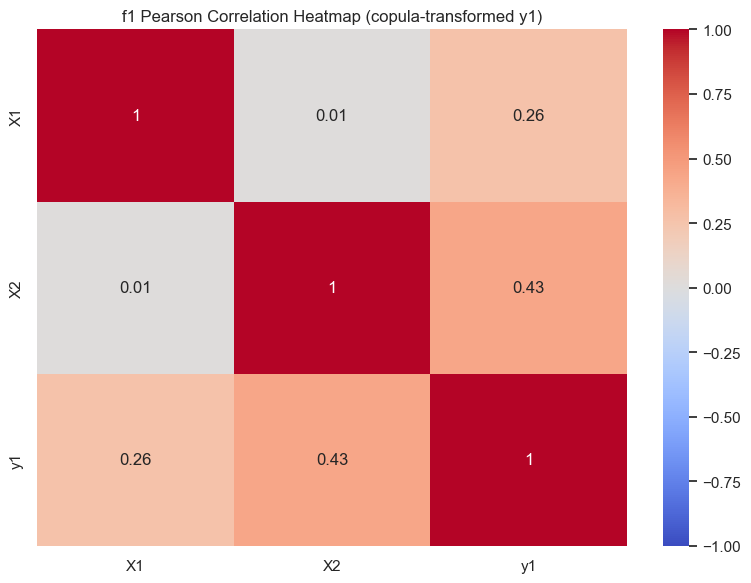

In [17]:
from scipy.stats import norm

df_copula = df_f1.copy()

y = df_copula["y1"].values

def gaussian_copula_transform(y):
    n = len(y)
    ranks = np.argsort(np.argsort(y)) + 1
    quantiles = ranks / (n + 1)
    return norm.ppf(quantiles)
    
y_copula = gaussian_copula_transform(y)

df_copula["y1"] = y_copula

print("f1 Pearson Correlation Matrix (copula-transformed y1)")

corr_copula = df_copula.corr()
display(corr_copula)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_copula,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f1 Pearson Correlation Heatmap (copula-transformed y1)")
plt.tight_layout()
plt.show()

## Spearman Correlation

f1 Spearman Correlation Matrix (raw y1)


,X1,X2,y1
X1,1.000000,-0.184280,0.191801
X2,-0.184280,1.000000,0.347368
y1,0.191801,0.347368,1.000000


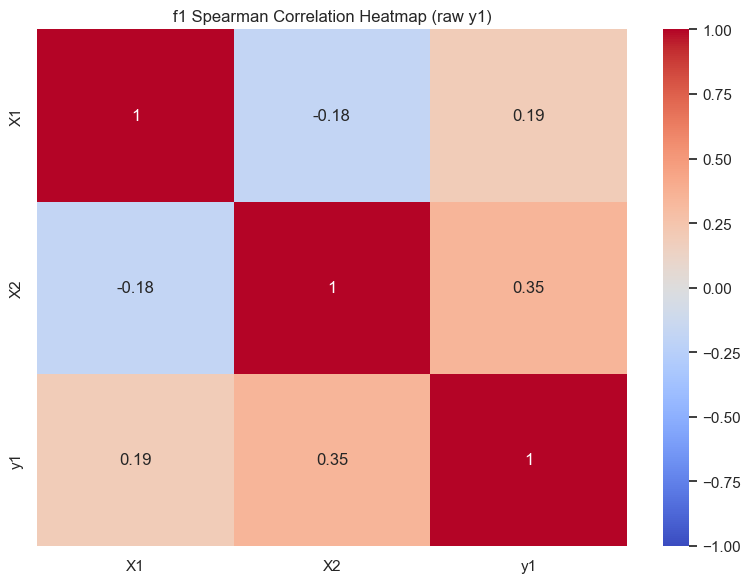

In [18]:
# spearman correlation with raw y1
df_raw = df_f1.copy()

print("f1 Spearman Correlation Matrix (raw y1)")

corr_raw_spearman = df_raw.corr(method="spearman")
display(corr_raw_spearman)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_spearman,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f1 Spearman Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


f1 Spearman Correlation Matrix (copula-transformed y1)


,X1,X2,y1
X1,1.000000,-0.184280,0.191801
X2,-0.184280,1.000000,0.347368
y1,0.191801,0.347368,1.000000


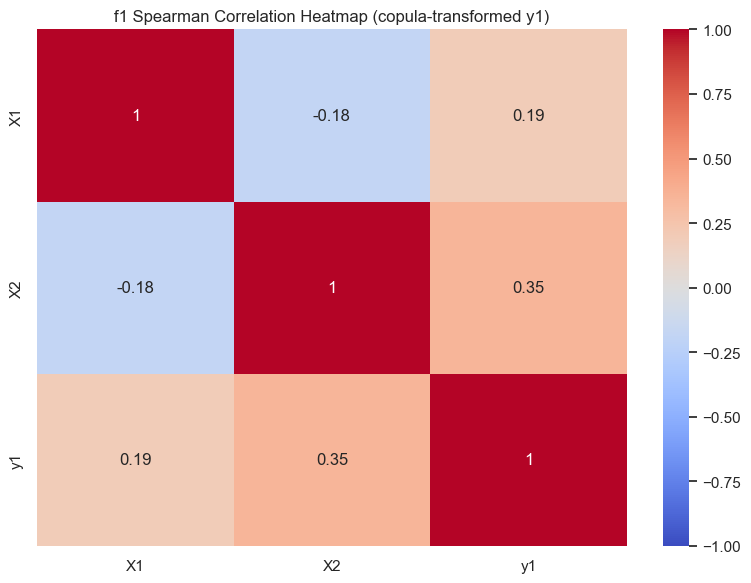

In [19]:
# spearman correlation with copula-transformed y1
df_copula = df_f1.copy()

y = df_copula["y1"].values
y_copula = gaussian_copula_transform(y)

df_copula["y1"] = y_copula

print("f1 Spearman Correlation Matrix (copula-transformed y1)")

corr_copula_spearman = df_copula.corr(method="spearman")
display(corr_copula_spearman)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_copula_spearman,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f1 Spearman Correlation Heatmap (copula-transformed y1)")
plt.tight_layout()
plt.show()


## Kendall Correlation

f1 Kendall Correlation Matrix (raw y1)


,X1,X2,y1
X1,1.000000,-0.163589,0.100264
X2,-0.163589,1.000000,0.200000
y1,0.100264,0.200000,1.000000


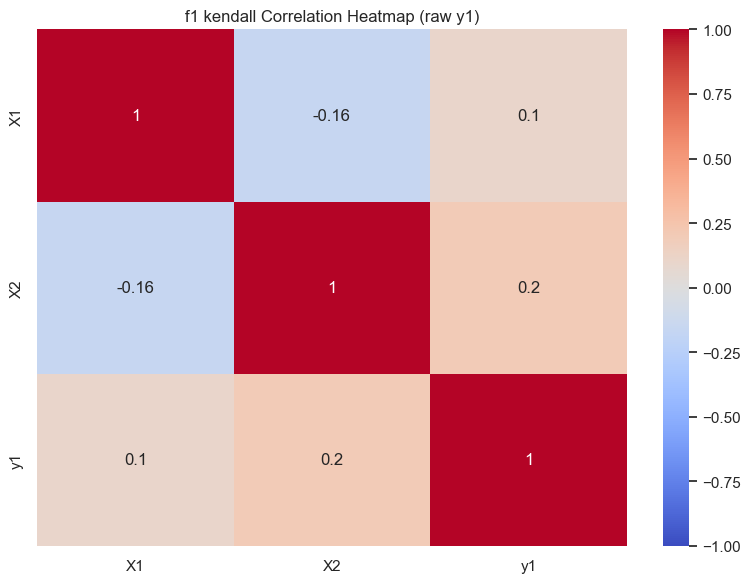

In [20]:
# Kendall correlation with raw y1
df_raw = df_f1.copy()

print("f1 Kendall Correlation Matrix (raw y1)")

corr_raw_kendall = df_raw.corr(method="kendall")
display(corr_raw_kendall)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_kendall,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f1 kendall Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


## Mutual Information 

In [21]:
from sklearn.feature_selection import mutual_info_regression

In [22]:
print("f1 (Copula-Transformed y1) — Mutual Information with Output")

# copy f1
df_f1_copula = df_f1.copy()

# apply copula transform
y = df_f1_copula["y1"].values
y_copula = gaussian_copula_transform(y)

df_f1_copula["y1"] = y_copula

# define inputs and output
input_cols_f1 = [c for c in df_f1_copula.columns if c.startswith("X")]
output_col_f1 = "y1"

X_f1 = df_f1_copula[input_cols_f1].values
y_f1 = df_f1_copula[output_col_f1].values

# compute mutual information
mi_f1_copula = mutual_info_regression(X_f1, y_f1, random_state=42)

# build dataframe
mi_f1_copula_df = pd.DataFrame({
    "Feature": input_cols_f1,
    "Mutual_Info": mi_f1_copula
}).sort_values(by="Mutual_Info", ascending=False)

display(mi_f1_copula_df)


f1 (Copula-Transformed y1) — Mutual Information with Output


,Feature,Mutual_Info
1,X2,0.342975
0,X1,0.025732


## Partial Correlation

In [23]:
!pip install pingouin
import pingouin as pg

In [24]:
print("f1 (Raw y1) — Partial Correlation")

# copy raw f1
df_f1_raw = df_f1.copy()

# define inputs and output
input_cols_f1 = [c for c in df_f1_raw.columns if c.startswith("X")]
output_col_f1 = "y1"

# compute partial correlations for each X feature
for x in input_cols_f1:
    covars = [c for c in input_cols_f1 if c != x]  # all other X's as covariates
    
    pcorr_raw_f1 = pg.partial_corr(
        data=df_f1_raw,
        x=x,
        y=output_col_f1,
        covar=covars
    )
    
    print(f"\nPartial correlation for {x}:")
    display(pcorr_raw_f1)



f1 (Raw y1) — Partial Correlation

Partial correlation for X1:


,n,r,CI95%,p-val
pearson,20,-0.030625,"[-0.48, 0.43]",0.900954



Partial correlation for X2:


,n,r,CI95%,p-val
pearson,20,-0.074088,"[-0.51, 0.39]",0.763083


In [25]:
print("f1 (Copula-Transformed y1) — Partial Correlation")

# copy f1
df_f1_copula = df_f1.copy()

# apply copula transform
y = df_f1_copula["y1"].values
y_copula = gaussian_copula_transform(y)

df_f1_copula["y1"] = y_copula

# define inputs and output
input_cols_f1 = [c for c in df_f1_copula.columns if c.startswith("X")]
output_col_f1 = "y1"

# compute partial correlations for each X feature
for x in input_cols_f1:
    covars = [c for c in input_cols_f1 if c != x]
    
    pcorr_copula_f1 = pg.partial_corr(
        data=df_f1_copula,
        x=x,
        y=output_col_f1,
        covar=covars
    )
    
    print(f"\nPartial correlation for {x}:")
    display(pcorr_copula_f1)


f1 (Copula-Transformed y1) — Partial Correlation

Partial correlation for X1:


,n,r,CI95%,p-val
pearson,20,0.282124,"[-0.2, 0.65]",0.24191



Partial correlation for X2:


,n,r,CI95%,p-val
pearson,20,0.442346,"[-0.01, 0.75]",0.057904


## Jackknife Correlation Stability


In [26]:
from scipy.stats import spearmanr

In [27]:
def jackknife_correlation_stability(x, y):
    """
    compute jackknife stability of the spearman correlation
    between a feature x and target y.

    the idea:
      remove one observation at a time
      recompute spearman correlation
      collect all jackknife correlations
      compute the standard deviation across them

    interpretation:
      std < 0.10  means stable signal
      std > 0.10  means unstable signal
    """

    x = np.asarray(x)
    y = np.asarray(y)
    n = len(x)

    # store jackknife correlations
    jackknife_rhos = []

    for i in range(n):
        # remove the i-th observation
        mask = np.ones(n, dtype=bool)
        mask[i] = False

        x_jk = x[mask]
        y_jk = y[mask]

        # compute spearman correlation on the reduced dataset
        rho, _ = spearmanr(x_jk, y_jk)
        jackknife_rhos.append(rho)

    jackknife_rhos = np.array(jackknife_rhos)
    rho_mean = jackknife_rhos.mean()
    rho_std = jackknife_rhos.std()

    print("jackknife correlation stability")
    print(f"original spearman rho: {spearmanr(x, y)[0]:.4f}")
    print(f"jackknife mean rho:    {rho_mean:.4f}")
    print(f"jackknife std rho:     {rho_std:.4f}")

    if rho_std > 0.10:
        print("signal is unstable (std > 0.10)")
    else:
        print("signal is stable (std <= 0.10)")

    return jackknife_rhos, rho_mean, rho_std

In [28]:
print("Jackknife Spearman Stability (raw y1)")

df_raw = df_f1.copy()
input_cols = [c for c in df_raw.columns if c.startswith("X")]
y = df_raw["y1"].values

for xcol in input_cols:
    print(f"Feature: {xcol}")
    x = df_raw[xcol].values
    jackknife_correlation_stability(x, y)

Jackknife Spearman Stability (raw y1)
Feature: X1
jackknife correlation stability
original spearman rho: 0.1918
jackknife mean rho:    0.1910
jackknife std rho:     0.0507
signal is stable (std <= 0.10)
Feature: X2
jackknife correlation stability
original spearman rho: 0.3474
jackknife mean rho:    0.3461
jackknife std rho:     0.0489
signal is stable (std <= 0.10)


## Pairwise scatter coloured by y rank


Feature vs y1 (Gaussian Copula) for f1


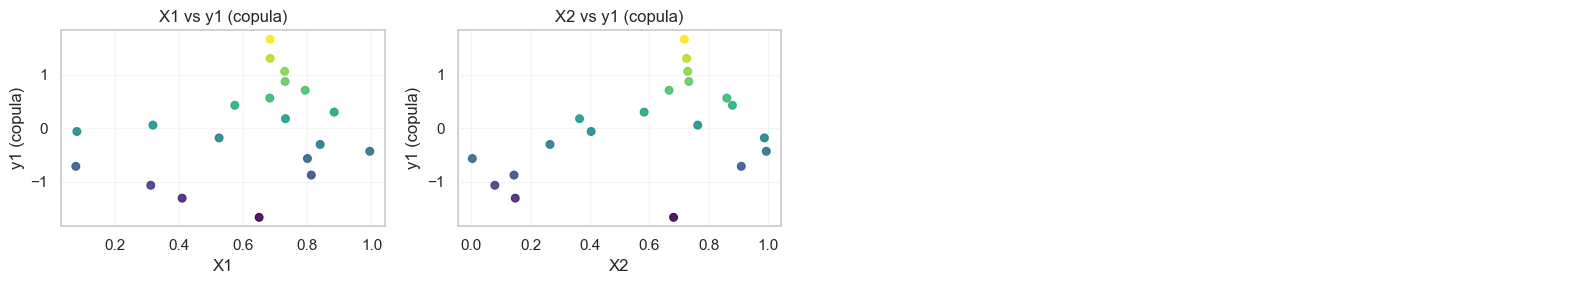

In [29]:
# === Feature vs copula-transformed y1 for f1 ===
print("\nFeature vs y1 (Gaussian Copula) for f1")

# number of input features
n_features = X_f1.shape[1]
ncols = 4
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

# robust flattening
if nrows * ncols == 1:
    axes = [axes]
else:
    axes = axes.ravel().tolist()

# plot each feature
for j, col in enumerate(input_cols_f1):
    ax = axes[j]
    sc = ax.scatter(
        X_f1[:, j],
        y_f1,
        c=y_f1,
        cmap="viridis",
        s=30,
        alpha=0.9
    )
    ax.set_xlabel(col)
    ax.set_ylabel("y1 (copula)")
    ax.set_title(f"{col} vs y1 (copula)")
    ax.grid(alpha=0.2)

# hide unused axes
for k in range(n_features, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()


## Log10(y) vs X2 in the Peak Neighbourhood

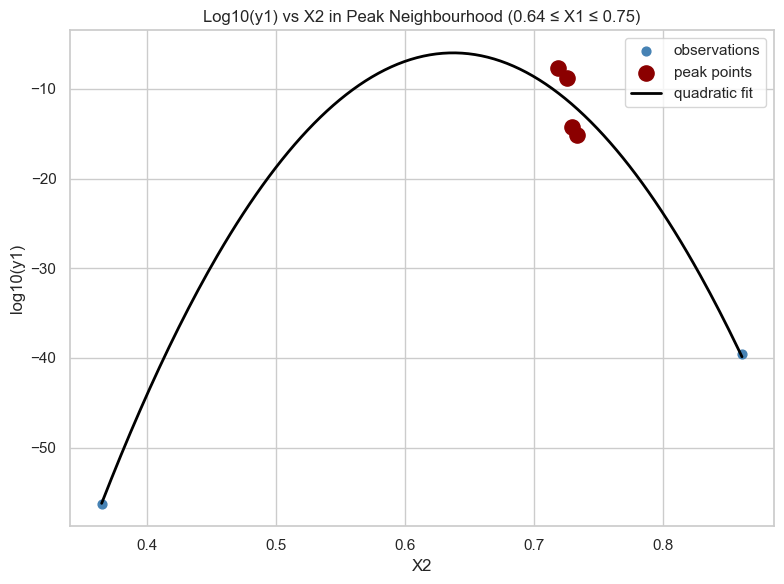

In [30]:
# restrict to peak neighbourhood
df_peak = df_f1[(df_f1["X1"] >= 0.64) & (df_f1["X1"] <= 0.75) & (df_f1["y1"] > 0)]

# compute log10(y)
df_peak["log10_y"] = np.log10(df_peak["y1"])

# identify the 3–4 peak observations (highest y)
df_peak_sorted = df_peak.sort_values("y1", ascending=False)
df_peaks = df_peak_sorted.head(4)

# quadratic fit: log10(y) = a + b*X2 + c*X2^2
X2_vals = df_peak["X2"].values
logy_vals = df_peak["log10_y"].values
coeffs = np.polyfit(X2_vals, logy_vals, deg=2)
poly = np.poly1d(coeffs)

# generate smooth curve
x2_grid = np.linspace(X2_vals.min(), X2_vals.max(), 200)
y_fit = poly(x2_grid)

# plot
plt.figure(figsize=(8, 6))

# all points
plt.scatter(df_peak["X2"], df_peak["log10_y"], s=40, color="steelblue", label="observations")

# highlight peak points
plt.scatter(df_peaks["X2"], df_peaks["log10_y"], s=120, color="darkred", label="peak points")

# quadratic curve
plt.plot(x2_grid, y_fit, color="black", linewidth=2, label="quadratic fit")

plt.xlabel("X2")
plt.ylabel("log10(y1)")
plt.title("Log10(y1) vs X2 in Peak Neighbourhood (0.64 ≤ X1 ≤ 0.75)")
plt.legend()
plt.tight_layout()
plt.show()


## Topological Data Analysis

In [31]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import networkx as nx

In [32]:
def build_mapper_graph(X, filter_vals, n_intervals=5, overlap_frac=0.1,
                       cluster_eps=0.1, cluster_min_samples=1):
    """
    simple mapper implementation:
      - 1D filter function
      - interval cover with overlap
      - DBSCAN clustering inside each interval
      - nodes represent clusters
      - edges connect nodes sharing data points
    """

    X = np.asarray(X)
    filter_vals = np.asarray(filter_vals)

    # compute interval boundaries
    fmin, fmax = filter_vals.min(), filter_vals.max()
    interval_length = (fmax - fmin) / n_intervals
    overlap = interval_length * overlap_frac

    intervals = []
    for i in range(n_intervals):
        start = fmin + i * interval_length - overlap
        end = fmin + (i + 1) * interval_length + overlap
        intervals.append((start, end))

    G = nx.Graph()
    node_id = 0

    # store cluster membership for edge construction
    interval_clusters = []

    for (start, end) in intervals:
        # points inside interval
        mask = (filter_vals >= start) & (filter_vals <= end)
        idxs = np.where(mask)[0]

        if len(idxs) == 0:
            interval_clusters.append([])
            continue

        X_sub = X[idxs]

        # cluster inside interval
        labels = DBSCAN(eps=cluster_eps, min_samples=cluster_min_samples).fit_predict(X_sub)
        unique_labels = set(labels)

        clusters = []
        for lab in unique_labels:
            if lab == -1:
                continue  # ignore noise
            cluster_indices = idxs[labels == lab]

            # add node
            G.add_node(node_id, indices=cluster_indices, size=len(cluster_indices))
            clusters.append(node_id)
            node_id += 1

        interval_clusters.append(clusters)

    # build edges: clusters sharing points
    for i in range(len(interval_clusters) - 1):
        for a in interval_clusters[i]:
            for b in interval_clusters[i + 1]:
                # check overlap in data indices
                A = set(G.nodes[a]["indices"])
                B = set(G.nodes[b]["indices"])
                if len(A & B) > 0:
                    G.add_edge(a, b)

    return G

Mapper for f1 (transformed y1)
  mapper diagnostics: nodes=20, edges=4, connected_components=16
  node size: mean=1.20, min=1, max=3
  top nodes by max y (node, size, mean_y, max_y):
    node 19: size=3, mean_y=1.3484, max_y=1.6684
    node 16: size=3, mean_y=0.8854, max_y=1.0676
    node 17: size=1, mean_y=0.5659, max_y=0.5659
    node 15: size=1, mean_y=0.4307, max_y=0.4307
    node 12: size=1, mean_y=0.3030, max_y=0.3030


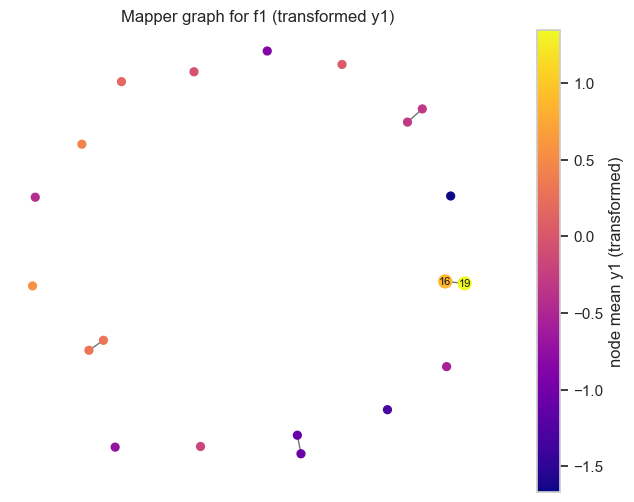

In [33]:
print("Mapper for f1 (transformed y1)")

# filter values = transformed y1
filter_vals = y_f1.copy()

# build mapper graph
G_f1 = build_mapper_graph(
    X_f1,
    filter_vals,
    n_intervals=5,
    overlap_frac=0.1,
    cluster_eps=0.1,
    cluster_min_samples=1
)

# diagnostics
n_nodes = G_f1.number_of_nodes()
n_edges = G_f1.number_of_edges()
n_components = nx.number_connected_components(G_f1)

print(f"  mapper diagnostics: nodes={n_nodes}, edges={n_edges}, connected_components={n_components}")

if n_nodes > 0:
    node_sizes = np.array([G_f1.nodes[n]["size"] for n in G_f1.nodes])
    print(f"  node size: mean={node_sizes.mean():.2f}, min={node_sizes.min():.0f}, max={node_sizes.max():.0f}")

    # compute node-level y statistics
    node_max_y = []
    node_mean_y = []

    for nkey in G_f1.nodes:
        idxs = G_f1.nodes[nkey]["indices"]
        node_max_y.append(float(filter_vals[idxs].max()))
        node_mean_y.append(float(filter_vals[idxs].mean()))

    node_max_y = np.array(node_max_y)
    node_mean_y = np.array(node_mean_y)

    # top 5 nodes by max y
    top_idx = np.argsort(node_max_y)[::-1][:5]
    print("  top nodes by max y (node, size, mean_y, max_y):")
    for t in top_idx:
        nkey = list(G_f1.nodes)[t]
        print(
            f"    node {nkey}: size={G_f1.nodes[nkey]['size']}, "
            f"mean_y={node_mean_y[t]:.4f}, max_y={node_max_y[t]:.4f}"
        )

# plot mapper graph
if n_nodes > 0:
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G_f1, seed=0)

    node_colors = [np.mean(filter_vals[G_f1.nodes[n]["indices"]]) for n in G_f1.nodes]
    node_sizes_plot = [
        5 + 80 * (G_f1.nodes[n]["size"] / node_sizes.max())
        for n in G_f1.nodes
    ]

    nodes = nx.draw_networkx_nodes(
        G_f1, pos,
        node_color=node_colors,
        cmap="plasma",
        node_size=node_sizes_plot
    )
    nx.draw_networkx_edges(G_f1, pos, alpha=0.6)

    # label only larger nodes
    labels = {
        n: f"{n}"
        for n in G_f1.nodes
        if G_f1.nodes[n]["size"] >= max(2, int(node_sizes.mean()))
    }
    nx.draw_networkx_labels(G_f1, pos, labels=labels, font_size=8)

    plt.colorbar(nodes, label="node mean y1 (transformed)")
    plt.title("Mapper graph for f1 (transformed y1)")
    plt.axis("off")
    plt.show()

# store results
results_f1_mapper = {
    "graph": G_f1,
    "filter_vals": filter_vals,
    "input_cols": input_cols_f1,
    "output_col": output_col_f1
}


## K-means Clustering

In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

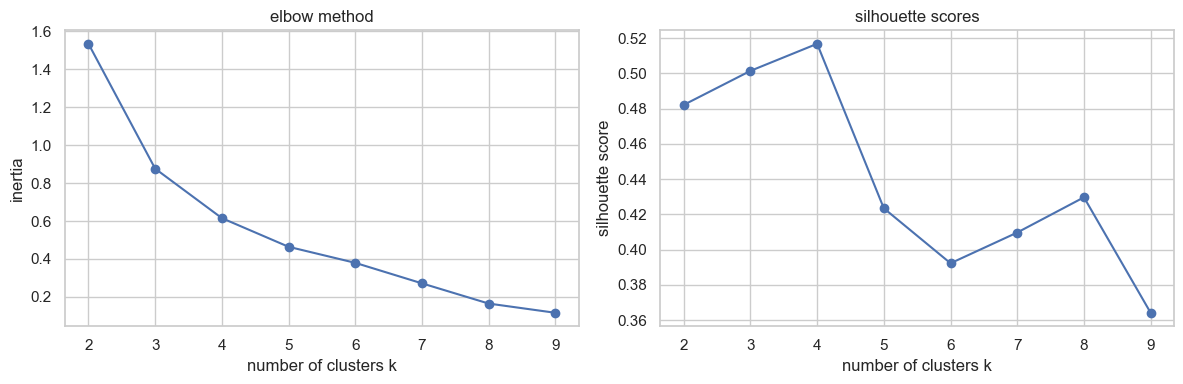

best number of clusters based on silhouette score: 4
cluster labels added to f1 dataframe


,X1,X2,y1,cluster
0,0.319404,0.762959,1.322677e-79,2
1,0.574329,0.879898,1.033078e-46,0
2,0.731024,0.733000,7.710875e-16,0
3,0.840353,0.264732,3.341771e-124,1
4,0.650114,0.681526,-3.606063e-03,0


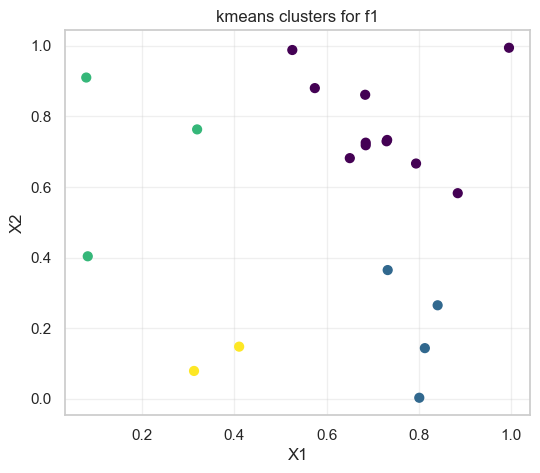

In [35]:
# prepare data
df_f1_kmeans = df_f1.copy()
input_cols_f1 = [c for c in df_f1_kmeans.columns if c.startswith("X")]
X_f1 = df_f1_kmeans[input_cols_f1].values

# test k from 2 to 9
k_values = range(2, 10)
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_f1)

    inertias.append(km.inertia_)

    labels = km.labels_
    score = silhouette_score(X_f1, labels)
    sil_scores.append(score)

# plot elbow + silhouette
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, marker="o")
plt.xlabel("number of clusters k")
plt.ylabel("inertia")
plt.title("elbow method")

plt.subplot(1, 2, 2)
plt.plot(k_values, sil_scores, marker="o")
plt.xlabel("number of clusters k")
plt.ylabel("silhouette score")
plt.title("silhouette scores")

plt.tight_layout()
plt.show()

# choose best k
best_k = k_values[np.argmax(sil_scores)]
print("best number of clusters based on silhouette score:", best_k)

# fit final model
kmeans_final = KMeans(n_clusters=best_k, random_state=42)
kmeans_final.fit(X_f1)

cluster_labels = kmeans_final.labels_

# add labels to dataframe
df_f1_kmeans["cluster"] = cluster_labels

print("cluster labels added to f1 dataframe")
display(df_f1_kmeans.head())

# optional scatter plot (only if 2D)
if X_f1.shape[1] == 2:
    plt.figure(figsize=(6, 5))
    plt.scatter(
        X_f1[:, 0], X_f1[:, 1],
        c=cluster_labels,
        cmap="viridis",
        s=40
    )
    plt.xlabel(input_cols_f1[0])
    plt.ylabel(input_cols_f1[1])
    plt.title("kmeans clusters for f1")
    plt.grid(alpha=0.3)
    plt.show()

## Pairwise Distance Distribution Among Top Observations

In [36]:
# select top 5 observations by y1
df_top = df_f1.sort_values("y1", ascending=False).head(5)

# extract X1 and X2 as a matrix
coords = df_top[["X1", "X2"]].values

# compute pairwise euclidean distances
dists = np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(axis=2))

# take upper triangle without diagonal
pairwise = dists[np.triu_indices(5, k=1)]

print("Pairwise distances among top 5 observations (X1, X2):")
print("mean distance:", pairwise.mean())
print("min distance:", pairwise.min())


Pairwise distances among top 5 observations (X1, X2):
mean distance: 0.062487690210985616
min distance: 0.003943488513332518


## Quadratic Residual Diagnostic (log10 space)

In [37]:
# extract X2 and log10(y) from the peak neighbourhood
df_peak = df_f1[(df_f1["X1"] >= 0.64) & (df_f1["X1"] <= 0.75) & (df_f1["y1"] > 0)].copy()
df_peak["log10_y"] = np.log10(df_peak["y1"])

X2_vals = df_peak["X2"].values
logy_vals = df_peak["log10_y"].values

# fit quadratic: log10(y) = a + b*X2 + c*X2^2
coeffs = np.polyfit(X2_vals, logy_vals, deg=2)
poly = np.poly1d(coeffs)

# predictions and residuals
y_pred = poly(X2_vals)
residuals = logy_vals - y_pred

# compute R-squared in log10 space
ss_res = np.sum((logy_vals - y_pred)**2)
ss_tot = np.sum((logy_vals - np.mean(logy_vals))**2)
r2 = 1 - ss_res/ss_tot

print("=== Quadratic Residual Diagnostic (log10 space) ===")
print(f"R-squared: {r2:.4f}")
print(f"max residual: {np.max(np.abs(residuals)):.4f} log units")
print(f"mean residual: {np.mean(np.abs(residuals)):.4f} log units")

if r2 >= 0.95:
    print("quadratic fit is strong (R² ≥ 0.95) — peak estimate is trustworthy")
elif r2 >= 0.90:
    print("quadratic fit is borderline (0.90 ≤ R² < 0.95) — use with caution")
else:
    print("quadratic fit is weak (R² < 0.90) — fallback step recommended")


=== Quadratic Residual Diagnostic (log10 space) ===
R-squared: 0.9853
max residual: 2.9170 log units
mean residual: 1.8361 log units
quadratic fit is strong (R² ≥ 0.95) — peak estimate is trustworthy


# Distrbution Analysis

f1 raw – feature and output distributions


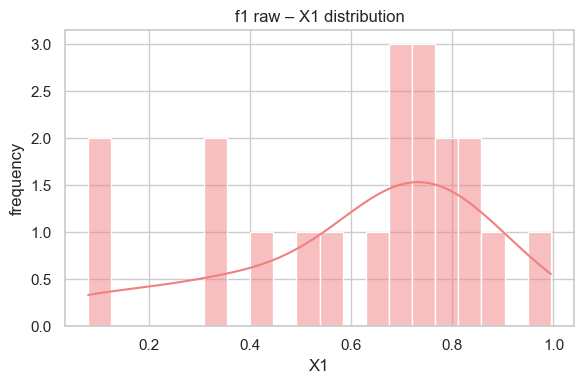

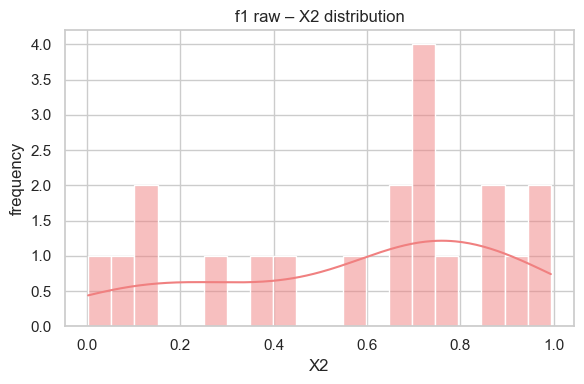

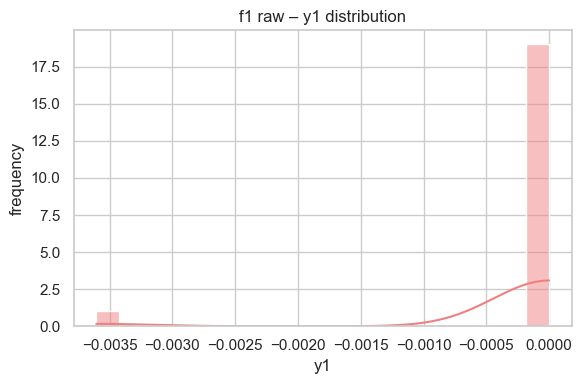

In [38]:
print("f1 raw – feature and output distributions")

all_cols_raw_f1 = input_cols + [output_cols[0]]   # EXACTLY your variables

for col in all_cols_raw_f1:
    plt.figure(figsize=(6, 4))

    sns.histplot(
        df_f1[col],
        kde=True,
        bins=20,
        color="lightcoral"
    )

    plt.title(f"f1 raw – {col} distribution")
    plt.xlabel(col)
    plt.ylabel("frequency")

    plt.tight_layout()
    plt.show()


f1 – raw inputs + log10(y1) distribution plots


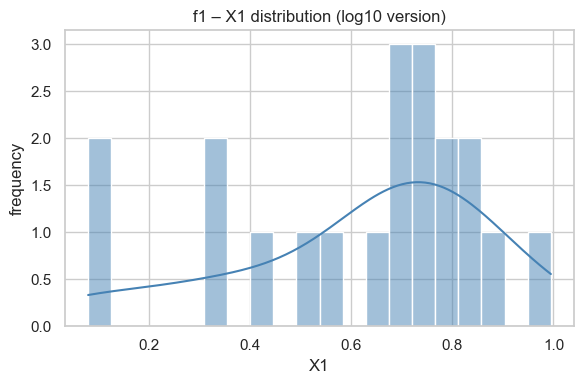

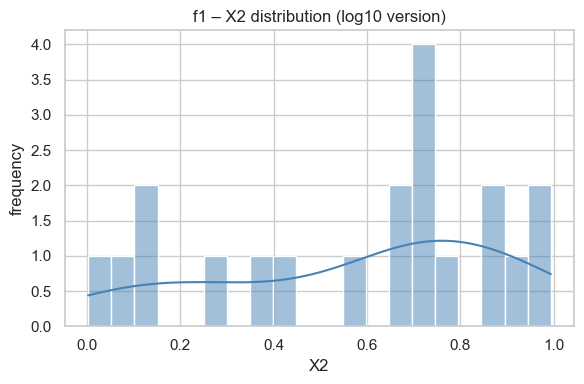

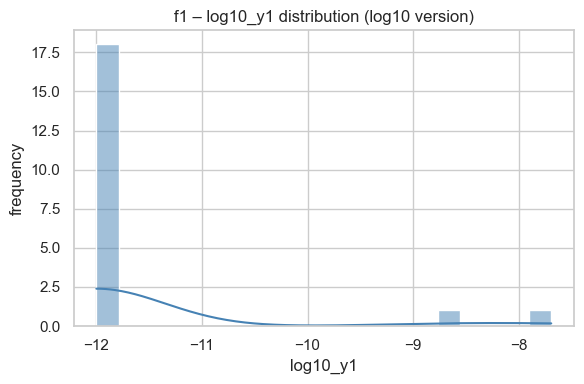

In [39]:
print("f1 – raw inputs + log10(y1) distribution plots")

df_log = df_f1.copy()
df_log["log10_y1"] = np.log10(df_log[output_cols[0]].clip(lower=1e-12))

cols_to_plot = input_cols + ["log10_y1"]

for col in cols_to_plot:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_log[col], kde=True, bins=20, color="steelblue")
    plt.title(f"f1 – {col} distribution (log10 version)")
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.tight_layout()
    plt.show()




### Line Plot of y Values

log10(y1) – y vs instance index


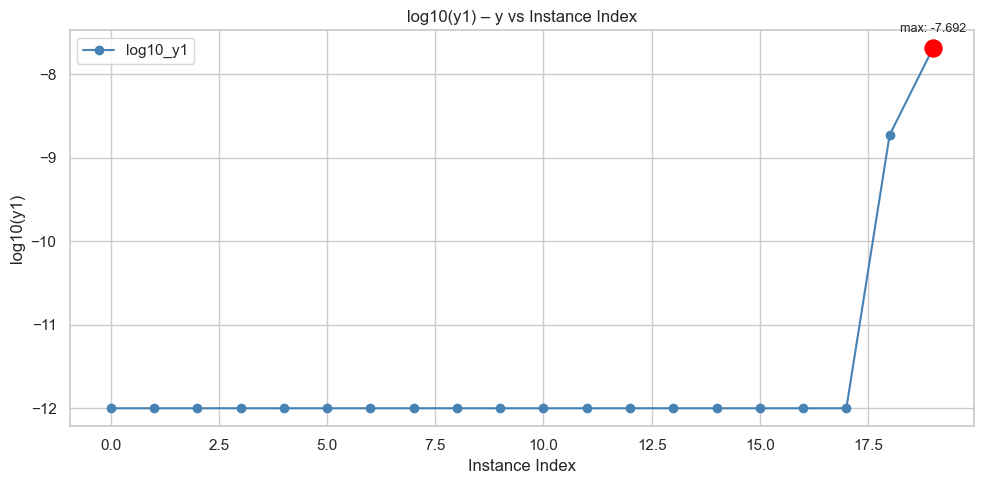

In [40]:
df_f1_log = df_f1.copy()

# log10 transform (safe for zeros)
df_f1_log["log10_y1"] = np.log10(df_f1_log[output_cols[0]].clip(lower=1e-12))

print("log10(y1) – y vs instance index")

y_log = df_f1_log["log10_y1"].values
x = np.arange(len(y_log))

plt.figure(figsize=(10, 5))

# line + points
plt.plot(x, y_log, marker="o", linestyle="-", color="steelblue", label="log10_y1")

# highlight maximum
max_idx = np.argmax(y_log)
max_val = y_log[max_idx]

plt.scatter(max_idx, max_val, s=150, color="red", zorder=5)
plt.annotate(
    f"max: {max_val:.3f}",
    (max_idx, max_val),
    textcoords="offset points",
    xytext=(0, 12),
    ha="center",
    fontsize=9
)

plt.title("log10(y1) – y vs Instance Index")
plt.xlabel("Instance Index")
plt.ylabel("log10(y1)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()





Gaussian Copula – y1 vs instance index


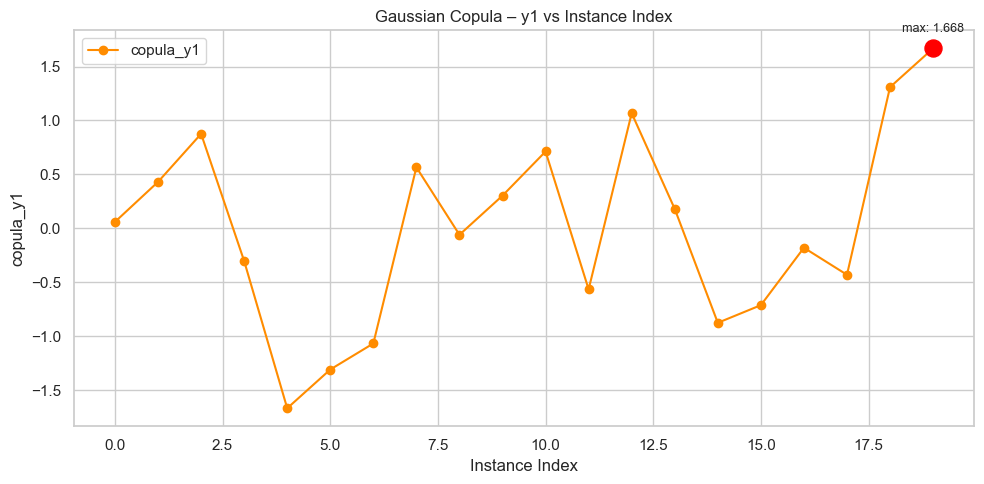

In [41]:
# 1. Create a clean copy of the RAW data
df_f1_copula_plot = df_f1.copy()

# 2. Apply Gaussian copula transform to y1 on the COPY
df_f1_copula_plot["copula_y1"] = gaussian_copula_transform(
    df_f1_copula_plot[output_cols[0]].values
)

print("Gaussian Copula – y1 vs instance index")

# 3. Extract transformed y
y_cop = df_f1_copula_plot["copula_y1"].values
x = np.arange(len(y_cop))

# 4. Plot
plt.figure(figsize=(10, 5))

plt.plot(x, y_cop, marker="o", linestyle="-", color="darkorange", label="copula_y1")

# highlight maximum
max_idx = np.argmax(y_cop)
max_val = y_cop[max_idx]

plt.scatter(max_idx, max_val, s=150, color="red", zorder=5)
plt.annotate(
    f"max: {max_val:.3f}",
    (max_idx, max_val),
    textcoords="offset points",
    xytext=(0, 12),
    ha="center",
    fontsize=9
)

plt.title("Gaussian Copula – y1 vs Instance Index")
plt.xlabel("Instance Index")
plt.ylabel("copula_y1")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#### f1 | Quadratic Ridge Extrapolation with Copula-Validated Bracketing

In [42]:
import numpy as np
from scipy.stats import norm
from scipy.stats.qmc import Sobol
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.preprocessing import StandardScaler

In [43]:
# Separate inputs (X) and outputs (y)
X_train_1 = df_f1[[c for c in df_f1.columns if c.startswith("X")]].values
y_train_1 = df_f1["y1"].values
print(X_train_1)
print(y_train_1)

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.7936     0.666269  ]
 [0.800601   0.0028    ]
 [0.729726   0.729276  ]
 [0.732162   0.364472  ]
 [0.81265    0.143347  ]
 [0.079265   0.909848  ]
 [0.525569   0.987823  ]
 [0.994902   0.994221  ]
 [0.684583   0.725353  ]
 [0.684583   0.718     ]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  1.40349865e-021  9.06910879e-223
  5.31459276e-015  5.47377612e-057 -1.06293312e-161  2.60788262e-248
  2.23603281e-098  3.02997127e-187  1.86704411e-009  2.03320460e-008]


In [44]:
from scipy.stats import norm


def select_peak_neighbourhood(X_train_1, y_train_1,
                               x1_centre=0.684583,
                               x1_radius=0.08,
                               x2_min=0.680,
                               x2_max=0.780,
                               min_y=0.0):
    """
    selects observations inside both an x1 band and an x2 window.
    the x2 window [0.680, 0.780] excludes row 7 (x2=0.861) and
    row 13 (x2=0.364) which polluted the original quadratic fit.
    x1_centre uses the exact best observed value 0.684583.
    """
    mask = (
        (np.abs(X_train_1[:, 0] - x1_centre) <= x1_radius) &
        (X_train_1[:, 1] >= x2_min) &
        (X_train_1[:, 1] <= x2_max) &
        (y_train_1 > min_y)
    )
    indices = np.where(mask)[0]
    return indices, X_train_1[mask], y_train_1[mask]


def fit_quadratic_log_y(x2_vals, y_vals):
    """
    fits a degree-2 polynomial to log10(y) as a function of x2.
    model: log10(y) = a * x2^2 + b * x2 + c
    peak at x2_peak = -b / (2a), valid only when a < 0.
    requires at least 3 observations.
    """
    if len(x2_vals) < 3:
        return None, None, None, False

    log_y = np.log10(y_vals)
    coeffs = np.polyfit(x2_vals, log_y, deg=2)
    a, b, c = coeffs

    if a >= 0:
        return coeffs, None, None, False

    x2_peak = -b / (2.0 * a)
    log_y_peak = np.polyval(coeffs, x2_peak)

    return coeffs, x2_peak, log_y_peak, True


def check_x2_separation(x2_proposed, X_train_1, x1_fixed,
                         min_x2_sep=0.008):
    """
    checks minimum x2 separation between the proposed x2 and all
    existing observations near the fixed x1 value.
    more appropriate than euclidean distance when x1 is fixed.
    returns the minimum separation and whether it is safe to submit.
    """
    near_x1 = np.abs(X_train_1[:, 0] - x1_fixed) < 0.05
    if near_x1.sum() == 0:
        return 1.0, True

    x2_existing = X_train_1[near_x1, 1]
    min_sep = np.abs(x2_existing - x2_proposed).min()
    is_safe = min_sep >= min_x2_sep

    return min_sep, is_safe


def propose_f1_query(X_train_1, y_train_1,
                                  x1_fixed=0.684583,
                                  x1_radius=0.08,
                                  x2_window=(0.680, 0.780),
                                  credible_x2_range=(0.680, 0.725),
                                  fallback_step=0.007,
                                  min_x2_sep=0.008,
                                  max_shift_attempts=10):
    """
    corrected week 11 strategy for f1.

    fixes applied versus the original version:
      1. x1_fixed uses exact best observed value 0.684583 not rounded 0.6846
      2. x2 window filter excludes outlier rows 7 and 13
      3. distance guard loops until separation >= min_x2_sep or
         max_shift_attempts is reached, rather than shifting only once
         the original code shifted once and accepted a still-unsafe separation
    """
    print("=== f1 week 11: corrected quadratic ridge extrapolation ===")
    print(f"x1 fixed at exact best observed value: {x1_fixed}")
    print(f"x2 window filter applied: {x2_window} to exclude outlier rows")

    best_idx = np.argmax(y_train_1)
    best_x = X_train_1[best_idx]
    best_y = y_train_1[best_idx]
    print(f"\ncurrent best: y={best_y:.4e} "
          f"at x1={best_x[0]:.6f}, x2={best_x[1]:.6f}")

    # step 1: select clean local observations using both x1 and x2 filters
    indices, X_local, y_local = select_peak_neighbourhood(
        X_train_1, y_train_1,
        x1_centre=x1_fixed,
        x1_radius=x1_radius,
        x2_min=x2_window[0],
        x2_max=x2_window[1],
        min_y=0.0
    )
    x2_local = X_local[:, 1]

    print(f"\nclean local observations after x2 window filter:")
    log_y_local = np.log10(y_local)
    for i, idx in enumerate(indices):
        print(f"  row {idx}: x2={X_train_1[idx, 1]:.4f}, "
              f"y={y_train_1[idx]:.4e}, log10(y)={log_y_local[i]:.4f}")

    # step 2: fit quadratic on the clean observations
    coeffs, x2_peak, log_y_peak, has_maximum = fit_quadratic_log_y(
        x2_local, y_local
    )
    a, b, c = coeffs

    # step 3: diagnostics on the clean fit
    print(f"\nquadratic fit on clean observations:")
    print(f"  a={a:.4f}, b={b:.4f}, c={c:.4f}")
    print(f"  a < 0: {a < 0} (required for a finite maximum)")

    log_y_fitted = np.polyval(coeffs, x2_local)
    residuals = log_y_local - log_y_fitted
    print(f"  residuals (log10 units): {np.round(residuals, 4)}")
    print(f"  max absolute residual: {np.abs(residuals).max():.4f}")

    if np.abs(residuals).max() > 2.0:
        print(f"  warning: large residuals, peak estimate not trusted")
        has_maximum = False

    if has_maximum:
        print(f"\n  estimated peak x2: {x2_peak:.6f}")
        print(f"  estimated peak log10(y): {log_y_peak:.4f}")
        print(f"  estimated peak y: {10**log_y_peak:.4e}")
        print(f"  improvement over current best: "
              f"{10**log_y_peak / best_y:.1f}x")

    # step 4: decide which x2 to submit
    if (has_maximum and
            credible_x2_range[0] <= x2_peak <= credible_x2_range[1]):
        x2_proposed = x2_peak
        method = "quadratic peak estimate"
        print(f"\nquadratic peak inside credible range {credible_x2_range}")
        print(f"using peak estimate: x2={x2_proposed:.6f}")
    else:
        x2_proposed = best_x[1] - fallback_step
        x2_proposed = np.clip(x2_proposed, 0.0, 1.0)
        method = "conservative gradient step"
        print(f"\nfallback: step {fallback_step} below current best x2")
        print(f"x2 proposed: {x2_proposed:.6f}")

    # step 5: x2 separation guard with loop
    # the original code shifted only once and accepted a still-unsafe separation
    # this version shifts repeatedly in steps of 0.005 until safe or
    # max_shift_attempts is exhausted
    x2_sep, is_safe = check_x2_separation(
        x2_proposed, X_train_1, x1_fixed, min_x2_sep
    )
    print(f"\nx2 separation from nearest same-x1 observation: {x2_sep:.6f}")

    shift_count = 0
    while not is_safe and shift_count < max_shift_attempts:
        x2_proposed -= 0.005
        x2_proposed = np.clip(x2_proposed, 0.0, 1.0)
        x2_sep, is_safe = check_x2_separation(
            x2_proposed, X_train_1, x1_fixed, min_x2_sep
        )
        shift_count += 1
        print(f"  shift {shift_count}: x2={x2_proposed:.6f}, "
              f"separation={x2_sep:.6f}, safe={is_safe}")

    if not is_safe:
        print(f"warning: could not achieve safe separation after "
              f"{max_shift_attempts} shifts")

    # step 6: construct final point using exact x1
    # x1_fixed is 0.684583, the exact value from rows 18 and 19
    # the original code used 0.6846 which rounds to 0.684600 in output
    next_x = np.array([x1_fixed, x2_proposed])

    # step 7: final summary
    print(f"\n--- final submission point ---")
    print(f"method: {method}")
    print(f"x1={next_x[0]:.6f}  (exact best observed value)")
    print(f"x2={next_x[1]:.6f}")
    print(f"x2 separation from nearest same-x1 observation: {x2_sep:.6f}")
    print(f"safe to submit: {is_safe}")
    print(f"total shifts applied: {shift_count}")

    print(f"\n--- confirmed x2 gradient (three observations) ---")
    peak_rows = [(0.7293, 5.315e-15), (0.7254, 1.867e-09), (0.7180, 2.033e-08)]
    prev = None
    for x2v, yv in peak_rows:
        ly = np.log10(yv)
        if prev:
            delta = ly - prev
            print(f"  x2={x2v:.4f}: log10(y)={ly:.4f}  delta={delta:+.4f}")
        else:
            print(f"  x2={x2v:.4f}: log10(y)={ly:.4f}  (baseline)")
        prev = ly
    print(f"  proposed x2={next_x[1]:.6f}: next probe in confirmed direction")

    return next_x

next_x = propose_f1_query(X_train_1, y_train_1)


=== f1 week 11: corrected quadratic ridge extrapolation ===
x1 fixed at exact best observed value: 0.684583
x2 window filter applied: (0.68, 0.78) to exclude outlier rows

current best: y=2.0332e-08 at x1=0.684583, x2=0.718000

clean local observations after x2 window filter:
  row 2: x2=0.7330, y=7.7109e-16, log10(y)=-15.1129
  row 12: x2=0.7293, y=5.3146e-15, log10(y)=-14.2745
  row 18: x2=0.7254, y=1.8670e-09, log10(y)=-8.7288
  row 19: x2=0.7180, y=2.0332e-08, log10(y)=-7.6918

quadratic fit on clean observations:
  a=-27250.6361, b=38986.8967, c=-13951.7004
  a < 0: True (required for a finite maximum)
  residuals (log10 units): [ 0.6591 -1.709   1.2763 -0.2264]
  max absolute residual: 1.7090

  estimated peak x2: 0.715339
  estimated peak log10(y): -7.2725
  estimated peak y: 5.3392e-08
  improvement over current best: 2.6x

quadratic peak inside credible range (0.68, 0.725)
using peak estimate: x2=0.715339

x2 separation from nearest same-x1 observation: 0.002661
  shift 1: x2=

In [45]:
# standardise copula transformed outputs to zero mean and unit variance
def standardise(y_copula):
    scaler = StandardScaler()
    y_scaled = scaler.fit_transform(y_copula.reshape(-1, 1)).ravel()
    return y_scaled, scaler


copula-normalised y table
    y_copula  y_normalized
0   0.059717      0.068745
1   0.430727      0.495844
2   0.876143      1.008597
3  -0.302980     -0.348785
4  -1.668391     -1.920616
5  -1.309172     -1.507091
6  -1.067571     -1.228964
7   0.565949      0.651508
8  -0.059717     -0.068745
9   0.302980      0.348785
10  0.712443      0.820149
11 -0.565949     -0.651508
12  1.067571      1.228964
13  0.180012      0.207226
14 -0.876143     -1.008597
15 -0.712443     -0.820149
16 -0.180012     -0.207226
17 -0.430727     -0.495844
18  1.309172      1.507091
19  1.668391      1.920616


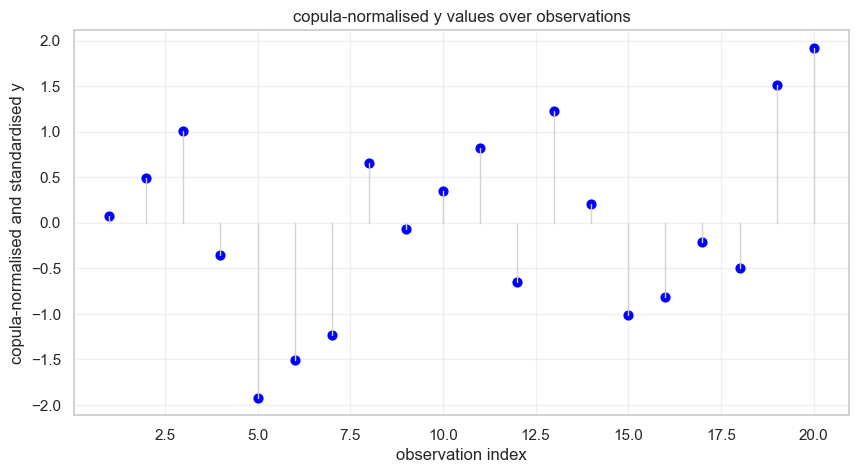

In [46]:
# apply copula transform
y_copula = gaussian_copula_transform(y_train_1)

# apply standardisation (extract only the scaled values)
y_normalized, _ = standardise(y_copula)

# x-axis values
x_vals = np.arange(1, len(y_normalized) + 1)

# build a table for inspection
results_table = pd.DataFrame({
    "y_copula": y_copula,
    "y_normalized": y_normalized
})

print("\ncopula-normalised y table")
print(results_table)

# create the plot
plt.figure(figsize=(10, 5))

# draw vertical lines from x-axis to each point
for x, y in zip(x_vals, y_normalized):
    plt.plot([x, x], [0, y], color="lightgray", linewidth=1)

# draw the points
plt.scatter(x_vals, y_normalized, color="blue", s=40)

# labels and title
plt.xlabel("observation index")
plt.ylabel("copula-normalised and standardised y")
plt.title("copula-normalised y values over observations")

# grid for readability
plt.grid(alpha=0.3)



In [ ]:
import numpy as np
from scipy.stats import norm

# paste the observed value returned by the competition after submitting next_query
y_actual = -1.0629331180647184e-161   # replace this each week

# get the gp prediction and uncertainty at the proposed point
# return_std=True is needed here because the original function does not return sigma
gp_pred, gp_sigma = gp.predict(next_query.reshape(1, -1), return_std=True)
gp_pred  = float(gp_pred[0])
gp_sigma = float(gp_sigma[0])

print("CALIBRATION ASSESSMENT")
print(f"  predicted mean : {gp_pred:.6e}")
print(f"  predicted std  : {gp_sigma:.6e}")
print(f"  observed value : {y_actual:.6e}")
print()


# negative log-likelihood
# measures how well the predictive distribution explains the observation
# negative values mean the model was confident and correct
# large positive values mean the model was overconfident or wrong

if gp_sigma > 0:
    nll = (0.5 * np.log(2 * np.pi * gp_sigma ** 2)
           + (y_actual - gp_pred) ** 2 / (2 * gp_sigma ** 2))
else:
    nll = np.inf

print(f"  NLL : {nll:.4f}")

if nll < 0:
    print("  verdict : EXCELLENT (< 0) high confidence, correct prediction")
elif nll < 5:
    print("  verdict : GOOD (0 to 5) reasonable calibration")
elif nll < 10:
    print("  verdict : MODERATE (5 to 10) some overconfidence")
else:
    print("  verdict : POOR (> 10) severe overconfidence, sigma too small")
print()


# z-score
# how many standard deviations the observation sits from the predicted mean
# values near zero mean the model uncertainty is well sized
# large absolute values mean the model was more confident than it should have been

if gp_sigma > 0:
    z_score = (y_actual - gp_pred) / gp_sigma
else:
    z_score = np.nan

print(f"  Z-Score : {z_score:.4f}")

if np.isnan(z_score):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif abs(z_score) <= 1.0:
    print("  verdict : EXCELLENT (|Z| <= 1) within 68% credible region")
elif abs(z_score) <= 1.96:
    print("  verdict : GOOD (|Z| <= 1.96) within 95% credible region")
elif abs(z_score) <= 3.0:
    print("  verdict : WARNING (1.96 < |Z| <= 3) mild miscalibration")
else:
    print("  verdict : SEVERE (|Z| > 3) extreme miscalibration")
print()


# 95% confidence interval coverage
# the observation should fall inside this interval roughly 95% of the time
# a single pass or fail is less informative than the trend across weeks

lower_95 = gp_pred - 1.96 * gp_sigma
upper_95 = gp_pred + 1.96 * gp_sigma
ci_pass  = bool(abs(z_score) <= 1.96) if not np.isnan(z_score) else False

print(f"  95% CI lower : {lower_95:.6e}")
print(f"  95% CI upper : {upper_95:.6e}")
print(f"  observed     : {y_actual:.6e}")

if ci_pass:
    print("  verdict : PASS, observation is inside the 95% confidence interval")
else:
    print("  verdict : FAIL, observation is outside the 95% confidence interval")
print()


# quantile position
# where the observation sits in the predicted cumulative distribution
# 0.5 means perfectly centred in the predictive distribution
# values near 0 mean the gp overestimated, values near 1 mean it underestimated
# for f1 specifically, values near 0.5 confirm the flat surface assumption

if gp_sigma > 0:
    quantile = norm.cdf(y_actual, loc=gp_pred, scale=gp_sigma)
else:
    quantile = np.nan

print(f"  Quantile : {quantile:.4f}")

if np.isnan(quantile):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif 0.40 <= quantile <= 0.60:
    print("  verdict : EXCELLENT (0.4 to 0.6) near median, perfectly centred")
elif 0.25 <= quantile <= 0.75:
    print("  verdict : GOOD (0.25 to 0.75) reasonably centred")
elif 0.025 <= quantile <= 0.975:
    print("  verdict : MODERATE, within 95% but off-centre")
elif quantile < 0.025:
    print("  verdict : POOR (< 0.025) extreme lower tail, gp overestimated")
else:
    print("  verdict : POOR (> 0.975) extreme upper tail, gp underestimated")
print()


# calibration gap
# the distance of the quantile from the ideal centre of 0.5
# zero means perfectly calibrated
# above 0.3 means significant directional bias
# for f1 this should stay below 0.15 given the flat and well-behaved surface

if not np.isnan(quantile):
    gap = abs(quantile - 0.5)
else:
    gap = np.nan

print(f"  Calibration Gap : {gap:.4f}")

if np.isnan(gap):
    print("  verdict : UNDEFINED")
elif gap < 0.05:
    print("  verdict : EXCELLENT (< 0.05) nearly perfect calibration")
elif gap < 0.10:
    print("  verdict : GOOD (0.05 to 0.10) well calibrated")
elif gap < 0.20:
    print("  verdict : MODERATE (0.10 to 0.20) some directional bias")
else:
    print("  verdict : POOR (> 0.20) significant miscalibration")
print()


# summary table
# all five metrics in one block for pasting into the weekly review log

print("CALIBRATION SUMMARY")
print(f"  {'metric':<20} {'value':>12}  {'verdict'}")
print(f"  {'-'*56}")
print(f"  {'NLL':<20} {nll:>12.4f}  {'EXCELLENT' if nll < 0 else 'GOOD' if nll < 5 else 'MODERATE' if nll < 10 else 'POOR'}")
print(f"  {'Z-Score':<20} {z_score:>12.4f}  {'EXCELLENT' if abs(z_score) <= 1 else 'GOOD' if abs(z_score) <= 1.96 else 'WARNING' if abs(z_score) <= 3 else 'SEVERE'}")
print(f"  {'95% CI':<20} {'PASS' if ci_pass else 'FAIL':>12}")
print(f"  {'Quantile':<20} {quantile:>12.4f}  {'EXCELLENT' if 0.4 <= quantile <= 0.6 else 'GOOD' if 0.25 <= quantile <= 0.75 else 'MODERATE' if 0.025 <= quantile <= 0.975 else 'POOR'}")
print(f"  {'Calibration Gap':<20} {gap:>12.4f}  {'EXCELLENT' if gap < 0.05 else 'GOOD' if gap < 0.10 else 'MODERATE' if gap < 0.20 else 'POOR'}")
print()


# flat surface decision rule for f1
# if the observed value is effectively zero, f1 is confirmed flat
# this triggers the week 6 pre-commitment to reallocate query budget

# this function performs the rank-based confirmation after receiving y_actual
def f1_rank_confirmation(y_train_1, y_actual):

    all_y = np.append(y_train_1, y_actual)
    rank_of_new = np.sum(all_y <= y_actual)
    rank_percentile = rank_of_new / len(all_y)

    return rank_percentile


flatness_threshold = 1e-10

print("FLAT SURFACE DECISION RULE")
if abs(y_actual) < flatness_threshold:
    print(f"  observed |y| = {abs(y_actual):.2e}  is below threshold {flatness_threshold:.0e}")
    print("  verdict  : f1 CONFIRMED FLAT")
    print("  action   : submit one verification query per week only")
else:
    print(f"  observed |y| = {abs(y_actual):.2e}  is above threshold {flatness_threshold:.0e}")
    print("  verdict  : UNEXPECTED NON-ZERO VALUE DETECTED")
    print("  action   : restart eda, do not dismiss this observation")
    print("  week 6   : ucb beta = 2.0 across full domain, 5 candidate pool")